# 生成对抗网络

**生成对抗网络**（GAN）的主要目标是生成与训练数据集相似（但不完全相同）的图像。

GAN由两个相互对抗训练的神经网络组成：

* **生成器**接收一个随机向量，并从中生成一张图像  
* **判别器**是一个神经网络，用于区分原始图像（来自训练数据集）和生成器生成的图像。


In [6]:
import torch
import torchvision
import matplotlib.pyplot as plt
from torchvision import transforms
from torch import nn
from torch import optim
from tqdm import tqdm
import numpy as np
import torch.nn.functional as F
torch.manual_seed(42)
np.random.seed(42)

In [9]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
train_size = 1.0
lr = 2e-4
weight_decay = 8e-9
beta1 = 0.5
beta2 = 0.999
batch_size = 256
epochs = 100
plot_every = 10

## 生成器

生成器的作用是接收一个随机向量（类似于自动编码器中的潜在向量），并生成目标图像。它与自动编码器的生成部分非常相似。

在我们的示例中，我们将使用线性神经网络和MNIST数据集。


In [10]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = nn.Linear(100, 256)
        self.bn1 = nn.BatchNorm1d(256, momentum=0.2)
        self.linear2 = nn.Linear(256, 512)
        self.bn2 = nn.BatchNorm1d(512, momentum=0.2)
        self.linear3 = nn.Linear(512, 1024)
        self.bn3 = nn.BatchNorm1d(1024, momentum=0.2)
        self.linear4 = nn.Linear(1024, 784)
        self.tanh = nn.Tanh()
        self.leaky_relu = nn.LeakyReLU(0.2)

    def forward(self, input):
        hidden1 = self.leaky_relu(self.bn1(self.linear1(input)))
        hidden2 = self.leaky_relu(self.bn2(self.linear2(hidden1)))
        hidden3 = self.leaky_relu(self.bn3(self.linear3(hidden2)))
        generated = self.tanh(self.linear4(hidden3)).view(input.shape[0], 1, 28, 28)
        return generated

生成器中使用的一些技巧：  
* 我们使用 **LeakyReLU** 替代 ReLU，也就是说，对于负值 $x$，它不是完全为 0，而是采用另一个具有非常小斜率的线性函数。  
* 我们使用 **BatchNorm1D** 来稳定训练过程。  
* 最后一层的激活函数是 **Tanh**，因此输出范围为 [-1,1]。  


## 判别器

判别器是一个经典的图像分类网络。在我们的第一个示例中，我们也将使用线性分类器。


In [11]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = nn.Linear(784, 512)
        self.linear2 = nn.Linear(512, 256)
        self.linear3 = nn.Linear(256, 1)
        self.leaky_relu = nn.LeakyReLU(0.2)
        self.sigmoid = nn.Sigmoid()

    def forward(self, input):
        input = input.view(input.shape[0], -1)
        hidden1 = self.leaky_relu(self.linear1(input))
        hidden2 = self.leaky_relu(self.linear2(hidden1))
        classififed = self.sigmoid(self.linear3(hidden2))
        return classififed

## 加载数据集

我们将使用 MNIST 数据集。


In [12]:
def mnist(train_part, transform=None):
    dataset = torchvision.datasets.CIFAR10('.', download=True, transform=transform)
    train_part = int(train_part * len(dataset))
    train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_part, len(dataset) - train_part])
    return train_dataset, test_dataset

In [13]:
transform = transforms.Compose([
                                transforms.ToTensor(),
                                transforms.Normalize(mean=0.5, std=0.5)
])

In [14]:
train_dataset, test_dataset = mnist(train_size, transform)

Files already downloaded and verified


In [15]:
train_dataloader = torch.utils.data.DataLoader(train_dataset, drop_last=True, batch_size=batch_size, shuffle=True)
dataloaders = (train_dataloader, )

In [16]:
import torchvision
Train_dataset=torchvision.datasets.CIFAR10(root=".",download=True,transform=torchvision.transforms.ToTensor(),train=True)
Test_dataset=torchvision.datasets.CIFAR10(root=".",download=True,transform=torchvision.transforms.ToTensor(),train=False)

Files already downloaded and verified
Files already downloaded and verified


## 网络训练

在每一步训练中，我们有**两个**阶段：

* **生成器**训练。我们生成一些随机向量**噪声**（训练以小批量进行，因此我们一次使用100个向量），生成**真实标签**（形状为 (bs, 1) 的向量，值为1.0），计算生成器损失，该损失是通过将噪声作为输入传入**冻结的**判别器并与真实标签进行比较得到的。

* **判别器**训练。我们从**两个**部分计算判别器损失，**第一**部分是判别器输出与噪声作为输入的**假标签**（形状为 (bs, 1) 的向量，值为0.0）之间的损失，**第二**部分是判别器输出与真实图像作为输入的真实标签（形状为 (bs, 1) 的向量，值为1.0）之间的损失。**最终损失**为 (第一部分损失 + 第二部分损失) / 2。


In [17]:
def plotn(n, generator, device):
    generator.eval()
    noise = torch.FloatTensor(np.random.normal(0, 1, (n, 100))).to(device)
    imgs = generator(noise).detach().cpu()
    fig, ax = plt.subplots(1, n)
    for i, im in enumerate(imgs):
        ax[i].imshow(im[0])
    plt.show()

In [18]:
def train_gan(dataloaders, models, optimizers, loss_fn, epochs, plot_every, device):
    tqdm_iter = tqdm(range(epochs))
    train_dataloader = dataloaders[0]
    
    gen, disc = models[0], models[1]
    optim_gen, optim_disc = optimizers[0], optimizers[1]

    for epoch in tqdm_iter:
        gen.train()
        disc.train()

        train_gen_loss = 0.0
        train_disc_loss = 0.0
        
        test_gen_loss = 0.0
        test_disc_loss = 0.0

        for batch in train_dataloader:
            imgs, _ = batch
            imgs = imgs.to(device)

            disc.eval()
            #冻结判别器，训练生成器
            gen.zero_grad()

            noise = torch.FloatTensor(np.random.normal(0.0, 1.0, (imgs.shape[0], 100))).to(device)
            real_labels = torch.ones((imgs.shape[0], 1)).to(device)
            fake_labels = torch.zeros((imgs.shape[0], 1)).to(device)
            
            generated = gen(noise)
            disc_preds = disc(generated)

            g_loss = loss_fn(disc_preds, real_labels)
            g_loss.backward()
            optim_gen.step()

            disc.train()
            #训练生成器
            disc.zero_grad()

            disc_real = disc(imgs)
            disc_real_loss = loss_fn(disc_real, real_labels)

            disc_fake = disc(generated.detach())
            disc_fake_loss = loss_fn(disc_fake, fake_labels)

            d_loss = (disc_real_loss + disc_fake_loss) / 2.0
            d_loss.backward()
            optim_disc.step()

            train_gen_loss += g_loss.item()
            train_disc_loss += d_loss.item()

        train_gen_loss /= len(train_dataloader)
        train_disc_loss /= len(train_dataloader)

        if epoch % plot_every == 0 or epoch == epochs - 1:
            plotn(5, gen, device)

        tqdm_dct = {'generator loss:': train_gen_loss, 'discriminator loss:': train_disc_loss}
        tqdm_iter.set_postfix(tqdm_dct, refresh=True)
        tqdm_iter.refresh()

In [19]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)
optimizer_generator = optim.Adam(generator.parameters(), lr=lr, weight_decay=weight_decay, betas=(beta1, beta2))
optimizer_discriminator = optim.Adam(discriminator.parameters(), lr=lr, weight_decay=weight_decay, betas=(beta1, beta2))
loss_fn = nn.BCELoss()

models = (generator, discriminator)
optimizers = (optimizer_generator, optimizer_discriminator)

In [20]:
train_gan(dataloaders, models, optimizers, loss_fn, epochs, plot_every, device)

  0%|          | 0/100 [00:00<?, ?it/s]


RuntimeError: mat1 and mat2 shapes cannot be multiplied (256x3072 and 784x512)

## DCGAN

**深度卷积生成对抗网络（Deep Convolutional GAN）** 是一个非常直观的想法，即在生成器和判别器中使用卷积层。这里的主要区别在于生成器中使用了 **Conv2DTranspose** 层。


> 图片来源于[本教程](https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html)


In [286]:
class DCGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.ConvTranspose2d(100, 256, kernel_size=(3, 3), stride=(2, 2), bias=False)
        self.bn1 = nn.BatchNorm2d(256)
        self.conv2 = nn.ConvTranspose2d(256, 128, kernel_size=(3, 3), stride=(2, 2), bias=False)
        self.bn2 = nn.BatchNorm2d(128)
        self.conv3 = nn.ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), bias=False)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.ConvTranspose2d(64, 1, kernel_size=(3, 3), stride=(2, 2), padding=(2, 2), output_padding=(1, 1), bias=False)
        self.tanh = nn.Tanh()
        self.relu = nn.ReLU()

    def forward(self, input):
        hidden1 = self.relu(self.bn1(self.conv1(input)))
        hidden2 = self.relu(self.bn2(self.conv2(hidden1)))
        hidden3 = self.relu(self.bn3(self.conv3(hidden2)))
        generated = self.tanh(self.conv4(hidden3)).view(input.shape[0], 1, 28, 28)
        return generated

In [287]:
class DCDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
        self.bn2 = nn.BatchNorm2d(128)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
        self.bn3 = nn.BatchNorm2d(256)
        self.conv4 = nn.Conv2d(256, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
        self.leaky_relu = nn.LeakyReLU(0.2)
        self.sigmoid = nn.Sigmoid()

    def forward(self, input):
        hidden1 = self.leaky_relu(self.conv1(input))
        hidden2 = self.leaky_relu(self.bn2(self.conv2(hidden1)))
        hidden3 = self.leaky_relu(self.bn3(self.conv3(hidden2)))
        classified = self.sigmoid(self.conv4(hidden3)).view(input.shape[0], -1)
        return classified

从[DCGAN](https://arxiv.org/pdf/1511.06434.pdf)论文中初始化权重。


In [288]:
def weights_init(model):
    classname = model.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(model.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(model.weight.data, 1.0, 0.02)
        nn.init.constant_(model.bias.data, 0)

In [289]:
transform = transforms.Compose([
                                transforms.ToTensor(),
])

In [290]:
train_dataset, test_dataset = mnist(train_size, transform)
train_dataloader = torch.utils.data.DataLoader(train_dataset, drop_last=True, batch_size=batch_size, shuffle=True)
dataloaders = (train_dataloader, )

In [291]:
generator = DCGenerator().to(device)
generator.apply(weights_init)
discriminator = DCDiscriminator().to(device)
discriminator.apply(weights_init)
optimizer_generator = optim.Adam(generator.parameters(), lr=lr, weight_decay=weight_decay, betas=(beta1, beta2))
optimizer_discriminator = optim.Adam(discriminator.parameters(), lr=lr, weight_decay=weight_decay, betas=(beta1, beta2))
loss_fn = nn.BCELoss()

models = (generator, discriminator)
optimizers = (optimizer_generator, optimizer_discriminator)

In [292]:
def dcplotn(n, generator, device):
    generator.eval()
    noise = torch.FloatTensor(np.random.normal(0, 1, (n, 100, 1, 1))).to(device)
    imgs = generator(noise).detach().cpu()
    fig, ax = plt.subplots(1, n)
    for i, im in enumerate(imgs):
        ax[i].imshow(im[0])
    plt.show()

In [293]:
def train_dcgan(dataloaders, models, optimizers, loss_fn, epochs, plot_every, device):
    tqdm_iter = tqdm(range(epochs))
    train_dataloader = dataloaders[0]
    
    gen, disc = models[0], models[1]
    optim_gen, optim_disc = optimizers[0], optimizers[1]
    
    gen.train()
    disc.train()

    for epoch in tqdm_iter:
        train_gen_loss = 0.0
        train_disc_loss = 0.0
        
        test_gen_loss = 0.0
        test_disc_loss = 0.0

        for batch in train_dataloader:
            imgs, _ = batch
            imgs = imgs.to(device)
            imgs = 2.0 * imgs - 1.0

            gen.zero_grad()

            noise = torch.FloatTensor(np.random.normal(0.0, 1.0, (imgs.shape[0], 100, 1, 1))).to(device)
            real_labels = torch.ones((imgs.shape[0], 1)).to(device)
            fake_labels = torch.zeros((imgs.shape[0], 1)).to(device)
            
            generated = gen(noise)
            disc_preds = disc(generated)

            g_loss = loss_fn(disc_preds, real_labels)
            g_loss.backward()
            optim_gen.step()

            disc.zero_grad()

            disc_real = disc(imgs)
            disc_real_loss = loss_fn(disc_real, real_labels)

            disc_fake = disc(generated.detach())
            disc_fake_loss = loss_fn(disc_fake, fake_labels)

            d_loss = (disc_real_loss + disc_fake_loss) / 2.0
            d_loss.backward()
            optim_disc.step()

            train_gen_loss += g_loss.item()
            train_disc_loss += d_loss.item()

        train_gen_loss /= len(train_dataloader)
        train_disc_loss /= len(train_dataloader)

        if epoch % plot_every == 0 or epoch == epochs - 1:
            dcplotn(5, gen, device)

        tqdm_dct = {'generator loss:': train_gen_loss, 'discriminator loss:': train_disc_loss}
        tqdm_iter.set_postfix(tqdm_dct, refresh=True)
        tqdm_iter.refresh()

  0%|          | 0/50 [00:00<?, ?it/s]

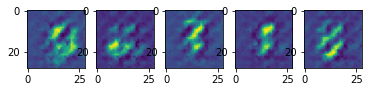

 10%|█         | 5/50 [00:53<08:03, 10.74s/it, generator loss:=2.38, discriminator loss:=0.256]

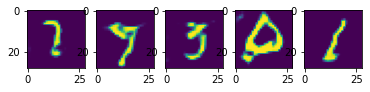

 20%|██        | 10/50 [01:47<07:03, 10.58s/it, generator loss:=2.12, discriminator loss:=0.254]

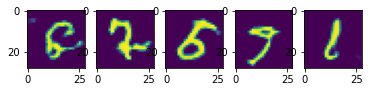

 30%|███       | 15/50 [02:40<06:12, 10.66s/it, generator loss:=2.2, discriminator loss:=0.255] 

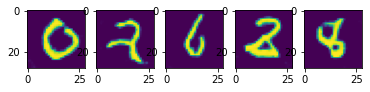

 40%|████      | 20/50 [03:33<05:17, 10.57s/it, generator loss:=2.21, discriminator loss:=0.266]

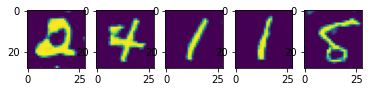

 50%|█████     | 25/50 [04:27<04:24, 10.60s/it, generator loss:=2.34, discriminator loss:=0.229]

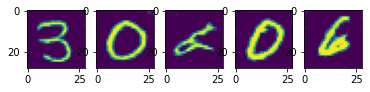

 60%|██████    | 30/50 [05:20<03:32, 10.65s/it, generator loss:=2.42, discriminator loss:=0.225]

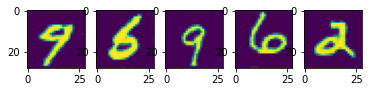

 70%|███████   | 35/50 [06:13<02:39, 10.60s/it, generator loss:=2.55, discriminator loss:=0.216]

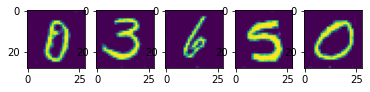

 80%|████████  | 40/50 [07:07<01:46, 10.62s/it, generator loss:=2.62, discriminator loss:=0.207]

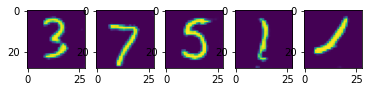

 90%|█████████ | 45/50 [08:00<00:52, 10.55s/it, generator loss:=2.8, discriminator loss:=0.178] 

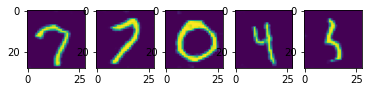

 98%|█████████▊| 49/50 [08:43<00:10, 10.65s/it, generator loss:=2.77, discriminator loss:=0.2]  

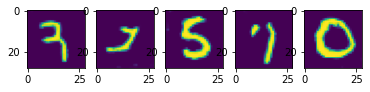

100%|██████████| 50/50 [08:54<00:00, 10.68s/it, generator loss:=2.79, discriminator loss:=0.184]


In [294]:
train_dcgan(dataloaders, models, optimizers, loss_fn, epochs // 2, plot_every // 2, device)

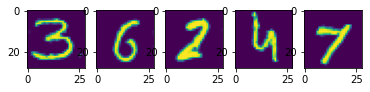

In [304]:
generator.eval()
dcplotn(5, generator, device)

> **任务**: 尝试使用DCGAN生成更复杂的彩色图像 - 例如，从[CIFAR-10](https://pytorch.org/vision/stable/generated/torchvision.datasets.CIFAR10.html)数据集中选择一个类别。


## 关于绘画的训练

GAN 训练的一个不错选择是由人类艺术家创作的绘画作品。

![](https://soshnikov.com/images/artartificial/Flo1.jpg)

（照片来自 [Art of Artificial](https://soshnikov.com/museum/art-artificial/) 收藏）


## 参考资料

* [GAN arxiv](https://arxiv.org/abs/1406.2661)  
* [DCGAN arxiv](https://arxiv.org/abs/1511.06434)  
* [DCGAN Pytorch 教程](https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html)  



---

**免责声明**：  
本文档使用AI翻译服务 [Co-op Translator](https://github.com/Azure/co-op-translator) 进行翻译。尽管我们努力确保翻译的准确性，但请注意，自动翻译可能包含错误或不准确之处。应以原始语言的文档作为权威来源。对于关键信息，建议使用专业人工翻译。我们对因使用此翻译而引起的任何误解或误读不承担责任。
